# Advanced Features

The package includes some optional features that will be demonstrated in this notebook. Starting with the optional components used during the fitting process, followed by optional settings in the generation process.

In [5]:
import matplotlib.pyplot as plt
from pyrex.eccentric_extension import generate_eccentric_waveform
from pyrex.eccentric_fit import fit_waveform_eccentricity
from qcextender.waveform import Waveform

## Specify $q$ and $e$

Standard behavior when not specifying $q$ and $e$ when calling `fit_waveform_eccentricity` is taking $q$ from SXS metadata and using the `gw_eccentricity` package for $e$. Specifying this manually ensures a common reference frequency.

In [6]:
sims = ["SXS:BBH:0180v2.0", "SXS:BBH:1355", "SXS:BBH:1357", "SXS:BBH:1362", "SXS:BBH:1363v2.0", "SXS:BBH:0184v2.0", "SXS:BBH:1364", "SXS:BBH:1368", "SXS:BBH:1369", "SXS:BBH:0183v2.0", "SXS:BBH:1373", "SXS:BBH:1374"]
q = [1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0]
e_ref = [0.0, 0.053, 0.097, 0.189, 0.192, 0.0, 0.044, 0.097, 0.185, 0.0, 0.093, 0.18]

training = fit_waveform_eccentricity(q=q, names=sims, e_ref=e_ref, outfname="sample_data/pyrexdata.pkl")

/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/sxs/simulations/simulation.py:203: UserWarning: 
Simulation 'SXS:BBH:0180' is deprecated, but you explicitly
requested version 'v2.0', so it is being used.
Pass `ignore_deprecation=True` to quiet this warning.

  warn(message)
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/gw_eccentricity/eccDefinition.py:1671: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through extrema. 
  debug_message(
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/sxs/simulations/simulation.py:203: UserWarning: 
Simulation 'SXS:BBH:1363' is deprecated, but you explicitly
requested version 'v2.0', so it is being used.
Pass `ignore_deprecation=True` to quiet this warning.

  warn(message)
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/sxs/simulations/simulation.py:203

## Cut

The pyrex waveform is automatically cut at $-1500M$, but this can be disabled when passing `cut = False` to `generate_eccentric_waveform`. This way the full behavior of the fitting parameterisation can be judged.

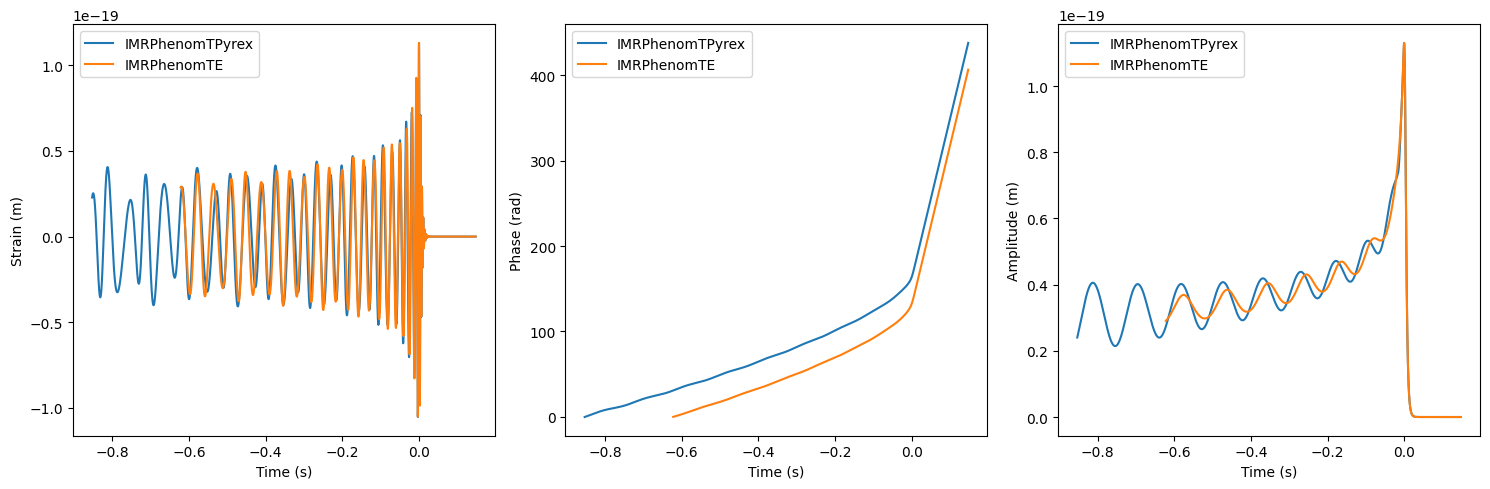

In [7]:
kwargs = {
    "approximant": "IMRPhenomTE",
    "mass1": 30,
    "mass2": 30,
    "inclination": 0,
    "coa_phase": 0,
    "delta_t": 1.0 / 4196,
    "f_lower": 20,
    "f_ref": 25,
    "distance": 10,
    "eccentricity": 0.1
}

phen = Waveform.from_model(**kwargs)
phen_ecc = generate_eccentric_waveform(dirfile="sample_data/pyrexdata.pkl", cut=False, **kwargs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phen_ecc.time, phen_ecc[2, 2], label="IMRPhenomTPyrex")
axes[0].plot(phen.time, phen[2, 2], label="IMRPhenomTE")
axes[0].set_ylabel("Strain (m)")
axes[0].set_xlabel("Time (s)")
axes[0].legend()

axes[1].plot(phen_ecc.time, phen_ecc.phase(), label="IMRPhenomTPyrex")
axes[1].plot(phen.time, phen.phase(), label="IMRPhenomTE")
axes[1].set_ylabel("Phase (rad)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

axes[2].plot(phen_ecc.time, phen_ecc.amp(), label="IMRPhenomTPyrex")
axes[2].plot(phen.time, phen.amp(), label="IMRPhenomTE")
axes[2].set_ylabel("Amplitude (m)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

plt.tight_layout()
plt.show()

## Interpolation

After re-evaluating the package the interpolation was changed to 2-dimensional instead of 1-dimensional. The behaviour of the 1-dimensional version can still be confirmed when passing `one_dimensional = True` to `generate_eccentric_waveform`.

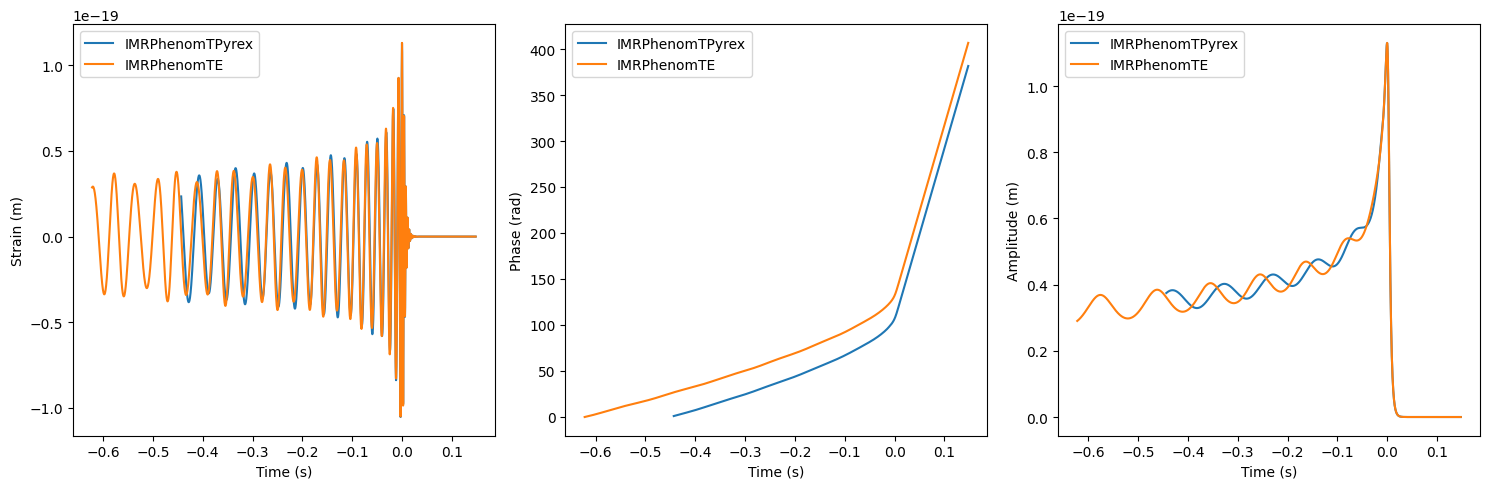

In [8]:
kwargs = {
    "approximant": "IMRPhenomTE",
    "mass1": 30,
    "mass2": 30,
    "inclination": 0,
    "coa_phase": 0,
    "delta_t": 1.0 / 4196,
    "f_lower": 20,
    "f_ref": 25,
    "distance": 10,
    "eccentricity": 0.1
}

phen = Waveform.from_model(**kwargs)
phen_ecc = generate_eccentric_waveform(dirfile="sample_data/pyrexdata.pkl", one_dimensional=True, **kwargs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phen_ecc.time, phen_ecc[2, 2], label="IMRPhenomTPyrex")
axes[0].plot(phen.time, phen[2, 2], label="IMRPhenomTE")
axes[0].set_ylabel("Strain (m)")
axes[0].set_xlabel("Time (s)")
axes[0].legend()

axes[1].plot(phen_ecc.time, phen_ecc.phase(), label="IMRPhenomTPyrex")
axes[1].plot(phen.time, phen.phase(), label="IMRPhenomTE")
axes[1].set_ylabel("Phase (rad)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

axes[2].plot(phen_ecc.time, phen_ecc.amp(), label="IMRPhenomTPyrex")
axes[2].plot(phen.time, phen.amp(), label="IMRPhenomTE")
axes[2].set_ylabel("Amplitude (m)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

plt.tight_layout()
plt.show()